<a href="https://colab.research.google.com/github/adharshraj77/FIFA_Anlysis/blob/main/FIFA_Modeling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modeling

#  Modeling Pipeline

##✅ Final Deliverables

| Deliverable              | Description                                    |
| ------------------------ | ---------------------------------------------- |
| 📄 Clustered Dataset     | Each player labeled with a cluster (role)      |
| 📊 Cluster Report        | Avg stats, cluster size, top players per group |
| 📈 Visualizations        | PCA + cluster insights                         |
| 🧠 (Optional) Classifier | Model to predict role group from stats         |


## Modeling Objective

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/fifa20Post_EDARes.csv")
df.head()

,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,RB,RM,RW,RWB,ST,tenure_years,log_value_eur,log_wage_eur,log_release_clause_eur,work_rate_combo
0,L. Messi,32,170,72,Argentina,FC Barcelona,80,85,95500000,565000,...,0,0,1,0,1,8.0,16.442245,11.065889,16.755719,1/0
1,Cristiano Ronaldo,34,187,83,Portugal,Juventus,80,85,58500000,405000,...,0,0,0,0,1,4.0,16.442245,11.065889,16.755719,2/0
2,Neymar Jr,27,175,68,Brazil,Paris Saint-Germain,80,85,105500000,290000,...,0,0,0,0,0,5.0,16.442245,11.065889,16.755719,2/1
3,J. Oblak,26,188,87,Slovenia,Atlético Madrid,80,85,77500000,125000,...,0,0,0,0,0,8.0,16.442245,11.065889,16.755719,1/1
4,E. Hazard,28,175,74,Belgium,Real Madrid,80,85,90000000,470000,...,0,0,0,0,0,5.0,16.442245,11.065889,16.755719,2/1


In [ ]:
df.shape


(17354, 116)

In [ ]:
df.describe()

,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,skill_moves,...,LWB,RB,RM,RW,RWB,ST,tenure_years,log_value_eur,log_wage_eur,log_release_clause_eur
count,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,1.735400e+04,17354.000000,17354.000000,17354.000000,17354.000000,...,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000
mean,25.307307,181.414198,75.258211,66.359571,71.590700,2.566709e+06,9758.672352,1.107295,2.949061,2.374323,...,0.017287,0.109542,0.127406,0.054051,0.016423,0.177365,3.594733,13.670471,8.257505,14.202525
std,4.609740,6.555548,6.829551,6.624531,6.007342,5.702584e+06,21803.306160,0.386201,0.666603,0.767819,...,0.130343,0.312328,0.333437,0.226125,0.127098,0.381989,2.024098,1.345868,1.191794,1.312198
min,16.000000,168.000000,60.000000,53.000000,58.000000,1.000000e+04,1000.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.927414,6.908755,11.606421
25%,22.000000,177.000000,70.000000,62.000000,67.000000,3.500000e+05,1000.000000,1.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12.765691,6.908755,13.322854
50%,25.000000,181.000000,75.000000,66.000000,71.000000,7.250000e+05,3000.000000,1.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,13.493928,8.006701,14.077876
75%,29.000000,186.000000,80.000000,71.000000,76.000000,2.200000e+06,8000.000000,1.000000,3.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,14.603968,8.987322,15.039286
max,36.000000,195.000000,90.000000,80.000000,85.000000,1.055000e+08,565000.000000,5.000000,5.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,16.442245,11.065889,16.755719


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17354 entries, 0 to 17353
Columns: 116 entries, short_name to work_rate_combo
dtypes: float64(44), int64(62), object(10)
memory usage: 15.4+ MB


In [ ]:
# df.drop(columns=['best_position', 'best_position_score'], inplace=True)


In [ ]:
df.columns.to_list()

['short_name',
 'age',
 'height_cm',
 'weight_kg',
 'nationality',
 'club',
 'overall',
 'potential',
 'value_eur',
 'wage_eur',
 'preferred_foot',
 'international_reputation',
 'weak_foot',
 'skill_moves',
 'body_type',
 'release_clause_eur',
 'team_position',
 'pace',
 'shooting',
 'passing',
 'dribbling',
 'defending',
 'physic',
 'gk_diving',
 'gk_handling',
 'gk_kicking',
 'gk_reflexes',
 'gk_speed',
 'gk_positioning',
 'attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_reactions',
 'movement_balance',
 'power_shot_power',
 'power_jumping',
 'power_stamina',
 'power_strength',
 'power_long_shots',
 'mentality_aggression',
 'mentality_interceptions',
 'mentality_positioning',
 'mentality_vision',
 'mentality_penalties',
 '

# Pre Modeling : Encoding And Scaling

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 📦 1. Preserve key identifiers for interpretation
df_reference = df[['short_name', 'nationality', 'club']].copy()

# 🛠️ 2. Copy for processing
df_encoded = df.copy()

# 🧼 3. Drop high-cardinality & identifier columns before PCA
df_encoded.drop(columns=['short_name', 'nationality', 'club'], inplace=True)

# 🔹 4. Label Encode simple binary columns
label_encode_cols = ['preferred_foot', 'body_type']
label_encoders = {}

for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # save if inverse needed

# 🔸 5. One-Hot Encode nominal multi-class features
one_hot_cols = ['role_group', 'attacking_work_rate', 'defensive_work_rate', 'primary_position' ,'best_position']
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=True)  # avoid dummy trap

# ✅ Summary
print("✅ Label & One-Hot Encoding complete.")
print(f"🔢 Final encoded shape: {df_encoded.shape}")
print(f"📌 Metadata retained in: {df_reference.columns.tolist()}")


✅ Label & One-Hot Encoding complete.
🔢 Final encoded shape: (17354, 138)
📌 Metadata retained in: ['short_name', 'nationality', 'club']


# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# 🔧 Copy encoded dataset to avoid altering original
df_scaled = df_encoded.copy()

# 🧪 Identify features to scale
numeric_cols = df_scaled.select_dtypes(include=['int64', 'float64']).columns

# 🧼 Exclude log-transformed columns (already compressed) and binary columns
exclude_cols = ['log_value_eur', 'log_wage_eur', 'log_release_clause_eur']
binary_cols = [col for col in df_scaled.columns if df_scaled[col].nunique() == 2]
scale_cols = [col for col in numeric_cols if col not in exclude_cols + binary_cols]

# 🧮 Apply StandardScaler
standard_scaler = StandardScaler()
df_scaled[scale_cols] = standard_scaler.fit_transform(df_scaled[scale_cols])

# Optionally scale log columns if you wish:
# df_scaled[exclude_cols] = standard_scaler.fit_transform(df_scaled[exclude_cols])

# 🧾 Final status
print("✅ Scaling applied to selected features.")
print(f"🔢 Scaled features: {len(scale_cols)}")
print(f"📊 Final dataset shape: {df_scaled.shape}")


✅ Scaling applied to selected features.
🔢 Scaled features: 87
📊 Final dataset shape: (17354, 138)


In [ ]:
df_reference.head()

,short_name,nationality,club
0,L. Messi,Argentina,FC Barcelona
1,Cristiano Ronaldo,Portugal,Juventus
2,Neymar Jr,Brazil,Paris Saint-Germain
3,J. Oblak,Slovenia,Atlético Madrid
4,E. Hazard,Belgium,Real Madrid


# Final Cleaning Before PCA

In [ ]:
# 1. Drop high-cardinality column
df_scaled.drop(columns=['team_position'], errors='ignore', inplace=True)
df_scaled.drop(columns=['work_rate_combo'], errors='ignore', inplace=True)

# 2. List of all boolean columns to fix
binary_columns = [
    'role_group_Defender', 'role_group_Goalkeeper', 'role_group_Midfielder',
    'attacking_work_rate_1', 'attacking_work_rate_2',
    'defensive_work_rate_1', 'defensive_work_rate_2',
    'primary_position_CB', 'primary_position_CDM', 'primary_position_CF',
    'primary_position_CM', 'primary_position_GK', 'primary_position_LB',
    'primary_position_LM', 'primary_position_LW', 'primary_position_LWB',
    'primary_position_RB', 'primary_position_RM', 'primary_position_RW',
    'primary_position_RWB', 'primary_position_ST',
    'best_position_lb', 'best_position_lcb', 'best_position_lcm',
    'best_position_ldm', 'best_position_lf', 'best_position_lm',
    'best_position_ls', 'best_position_lw', 'best_position_lwb'
]

# 3. Keep only those columns that actually exist
existing_cols = [col for col in binary_columns if col in df_scaled.columns]

# 4. Drop rows with non-boolean values in these columns
for col in existing_cols:
    df_scaled = df_scaled[df_scaled[col].isin([True, False])]

# 5. Convert True/False to 1/0
df_scaled[existing_cols] = df_scaled[existing_cols].astype(int)

print("✅ Cleaned and converted all relevant boolean columns.")
print("📊 Final shape of df_scaled:", df_scaled.shape)


✅ Cleaned and converted all relevant boolean columns.
📊 Final shape of df_scaled: (17354, 136)


In [ ]:
df_scaled.columns.tolist()

['age',
 'height_cm',
 'weight_kg',
 'overall',
 'potential',
 'value_eur',
 'wage_eur',
 'preferred_foot',
 'international_reputation',
 'weak_foot',
 'skill_moves',
 'body_type',
 'release_clause_eur',
 'pace',
 'shooting',
 'passing',
 'dribbling',
 'defending',
 'physic',
 'gk_diving',
 'gk_handling',
 'gk_kicking',
 'gk_reflexes',
 'gk_speed',
 'gk_positioning',
 'attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_reactions',
 'movement_balance',
 'power_shot_power',
 'power_jumping',
 'power_stamina',
 'power_strength',
 'power_long_shots',
 'mentality_aggression',
 'mentality_interceptions',
 'mentality_positioning',
 'mentality_vision',
 'mentality_penalties',
 'mentality_composure',
 'defending_marking',
 'defending_st

In [ ]:
# # ✅ Save and download the cleaned dataset
# from google.colab import files

# df_scaled.to_csv("Fifa_Scaled.csv", index=False)
# files.download("Fifa_Scaled.csv")

## Final Dataset OverView
#🔍 Dataset Overview:
Shape: (17,354 rows × 138 columns)

Missing Values: 0 ✅

###Data Types:
90 float features (✅ suitable for PCA),
30 boolean features (likely from one-hot encoding),
16 integer features,
2 object columns (possibly 'short_name', 'club' or 'nationality' — metadata, excluded from PCA)



##🧠  What is PCA (Principal Component Analysis)?
####PCA is a dimensionality reduction technique used to:
1.Reduce the number of features while preserving most of the variance

2.Decorrelate features (make them orthogonal)

3.Improve speed and performance of models

4.Help with clustering and visualization (via 2D/3D plots)

#Findind the Best PCA For th Current Dataset


| Variant                             | Description                                                                       | When to Use                                                     | Suitable for This Project?                                                        |
| ----------------------------------- | --------------------------------------------------------------------------------- | --------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| ✅ **Standard PCA**                  | Finds linear combinations (principal components) of features to maximize variance | Most datasets with numerical features                           | **Yes — best suited here**                                                        |
| 🔵 **Whitened PCA** (`whiten=True`) | Scales components to unit variance (removes all correlation)                      | When clustering or distance-based models are sensitive to scale | Optional — not necessary here                                                     |
| ⚙️ **Incremental PCA**              | PCA in mini-batches (for huge datasets)                                           | When data is too big to fit into memory                         | Not needed (your data fits in memory)                                             |
| 🌀 **Kernel PCA**                   | Non-linear transformation using kernel trick (RBF, poly kernels)                  | When relationships between features are non-linear              | Not needed unless you’re dealing with image/text embeddings or high non-linearity |
| 🧬 **Sparse PCA**                   | Adds sparsity constraint on components (less load per feature)                    | For high interpretability of each component                     | Could be useful, but not needed now                                               |
| 🌐 **Truncated SVD**                | Like PCA but for sparse matrices (e.g., NLP)                                      | Text embeddings or extremely sparse features                    | Not applicable here                                                               |
| 🎛️ **Factor Analysis**             | Models latent variables and assumes noise                                         | Used for psychological/latent factor modeling                   | Not recommended — different goal                                                  |


#🔹 Step 1: Fit PCA on Scaled Data

## Compare PCA Variance Levels:

🔢 Components to retain:
✅ 70% variance: 4 components
✅ 95% variance: 28 components
✅ 99% variance: 60 components


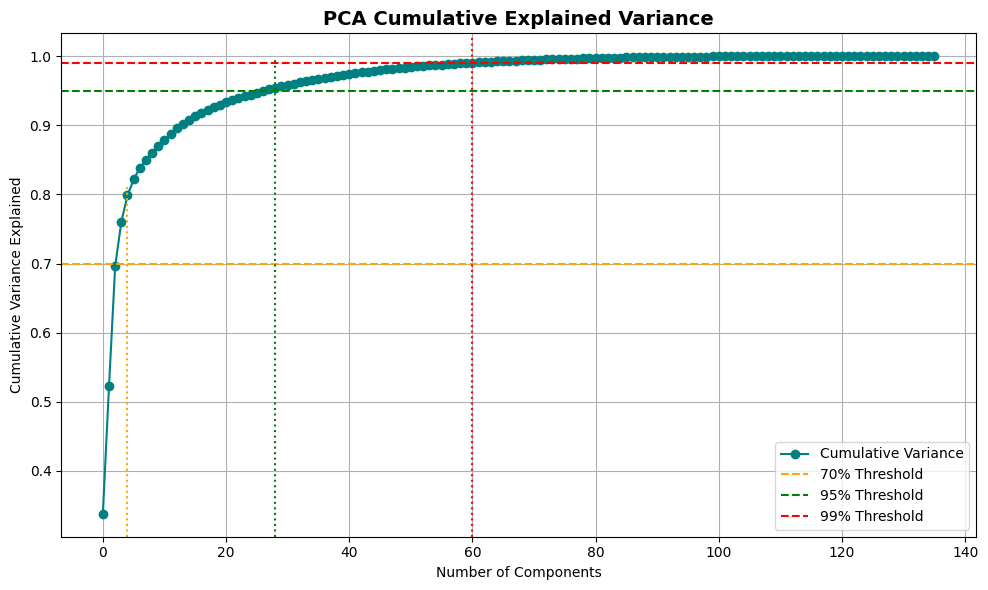

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming df_pca is your scaled PCA-ready DataFrame (all numeric)
# Exclude non-numeric columns if any accidentally remain
df_pca_clean = df_scaled.select_dtypes(include=['float64', 'int64'])

# Fit PCA
pca_full = PCA().fit(df_pca_clean)
explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_variance = explained_var_ratio.cumsum()

# Find components for 90%, 95%, 99%
n_components_70 = next(i for i, total_var in enumerate(cumulative_variance) if total_var >= 0.70) + 1
n_components_95 = next(i for i, total_var in enumerate(cumulative_variance) if total_var >= 0.95) + 1
n_components_99 = next(i for i, total_var in enumerate(cumulative_variance) if total_var >= 0.99) + 1

# 🎯 Display results
print("🔢 Components to retain:")
print(f"✅ 70% variance: {n_components_70} components")
print(f"✅ 95% variance: {n_components_95} components")
print(f"✅ 99% variance: {n_components_99} components")

# 📊 Plot Cumulative Variance
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='-', color='teal', label='Cumulative Variance')

# Add threshold lines
plt.axhline(0.70, color='orange', linestyle='--', label='70% Threshold')
plt.axhline(0.95, color='green', linestyle='--', label='95% Threshold')
plt.axhline(0.99, color='red', linestyle='--', label='99% Threshold')

# Annotate number of components
plt.axvline(n_components_70, color='orange', linestyle=':', ymax=0.70)
plt.axvline(n_components_95, color='green', linestyle=':', ymax=0.95)
plt.axvline(n_components_99, color='red', linestyle=':', ymax=0.99)

# Labels
plt.title("PCA Cumulative Explained Variance", fontsize=14, fontweight='bold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#🧩 Step 2: Transform the data using PCA (retain 23 components)

In [ ]:
from sklearn.decomposition import PCA

# 🎯 Retain 95% variance (30components)
pca_final = PCA(n_components=3)
pca_transformed = pca_final.fit_transform(df_pca_clean)

# ✅ Convert back to DataFrame for clarity
pca_df = pd.DataFrame(pca_transformed, columns=[f'PC{i+1}' for i in range(3)])

# 🧾 Attach player names back for later interpretation
pca_df['short_name'] = df_reference['short_name'].values

# Optional: reset index if needed
pca_df.reset_index(drop=True, inplace=True)

# 📌 Output shape check
print("✅ Final PCA Shape:", pca_df.shape)
pca_df.head()


✅ Final PCA Shape: (17354, 4)


,PC1,PC2,PC3,short_name
0,19.309649,5.310573,-0.707920,L. Messi
1,11.374448,-1.284765,-5.250676,Cristiano Ronaldo
2,12.180013,-1.152780,-6.349238,Neymar Jr
3,-3.111566,14.680665,2.091544,J. Oblak
4,11.957270,-1.039268,-5.375323,E. Hazard


In [ ]:
pca_df.shape

(17354, 4)

In [ ]:
# # ✅ Save and download the cleaned dataset
# from google.colab import files

# pca_df.to_csv("Post_PCA.csv", index=False)
# files.download("Post_PCA.csv")

#Clusterig

##🔢 Step 1: Determine Optimal Number of Clusters
###🔍 Why this matters:
Choosing the right number of clusters is crucial — too few and you oversimplify, too many and you overfit. We’ll use two trusted methods:

Elbow Method: Measures how much the model improves as you increase clusters (k) by checking inertia (within-cluster sum of squares).

Look for the elbow point (where gains sharply diminish).

Silhouette Score: Measures how well-separated clusters are. Higher score = better clustering.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



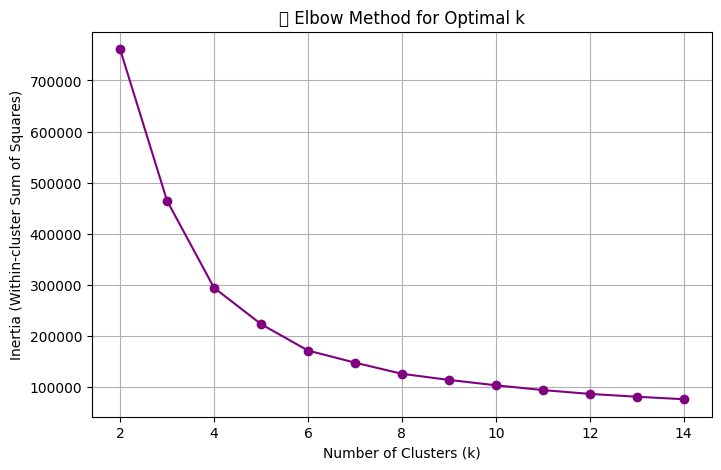

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



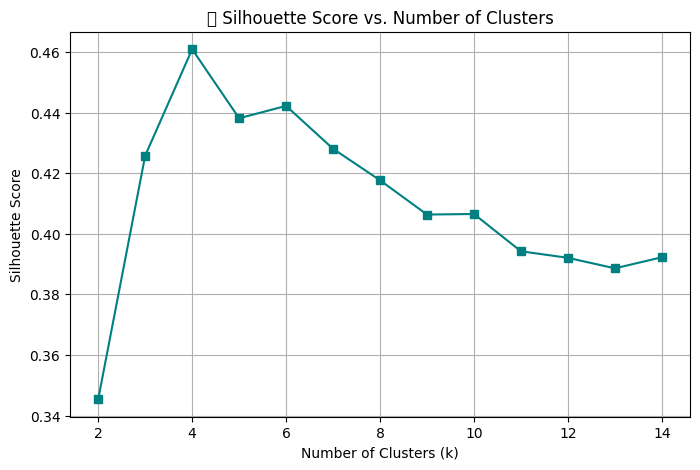

k=2: silhouette score = 0.3454
k=3: silhouette score = 0.4258
k=4: silhouette score = 0.4609
k=5: silhouette score = 0.4381
k=6: silhouette score = 0.4422
k=7: silhouette score = 0.4281
k=8: silhouette score = 0.4177
k=9: silhouette score = 0.4064
k=10: silhouette score = 0.4065
k=11: silhouette score = 0.3942
k=12: silhouette score = 0.3921
k=13: silhouette score = 0.3886
k=14: silhouette score = 0.3923


(17354, 3)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 📦 Use PCA data without short_name
X = pca_df.drop(columns=['short_name'])

# 📈 1. Elbow Method: Inertia Plot
inertias = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='purple')
plt.title('🔍 Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.grid(True)
plt.show()

# 📈 2. Silhouette Scores for Each k
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='s', color='teal')
plt.title('📊 Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# 📌 Output Silhouette Scores
for i, score in enumerate(silhouette_scores, start=2):
    print(f"k={i}: silhouette score = {score:.4f}")

X.shape

In [ ]:
X.shape

(17354, 3)

## Modeling

#

In [ ]:
train_set = pca_df.copy()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px

# 🎯 Use the pre-split train_set
X_train = train_set.drop(columns=['short_name']).reset_index(drop=True)
short_names = train_set['short_name'].reset_index(drop=True)

# Define the clustering algorithms
cluster_algorithms = {
    "KMeans": KMeans(n_clusters=4, random_state=42),
    "Agglomerative": AgglomerativeClustering(n_clusters=4),
    "GaussianMixture": GaussianMixture(n_components=4, random_state=42),
    "Spectral": SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=42)
}

# Store results
results = []

for name, model in cluster_algorithms.items():
    if name == "GaussianMixture":
        labels = model.fit_predict(X_train)
    else:
        labels = model.fit(X_train).labels_

    silhouette = silhouette_score(X_train, labels)
    db_index = davies_bouldin_score(X_train, labels)

    results.append({
        "Algorithm": name,
        "Silhouette Score": round(silhouette, 4),
        "Davies-Bouldin Index": round(db_index, 4)
    })

# 📌 Summary of Clustering Metrics
metrics_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
print("📈 Clustering Performance Summary:")
print(metrics_df)


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



📈 Clustering Performance Summary:
         Algorithm  Silhouette Score  Davies-Bouldin Index
0           KMeans            0.4609                0.7152
3         Spectral            0.4473                0.7292
1    Agglomerative            0.3855                0.8583
2  GaussianMixture            0.2769                1.5241


#📦 KMeans Clustering (Interactive 3D View)

In [ ]:
from sklearn.cluster import KMeans
import plotly.express as px

# Prepare data
X_kmeans = train_set.drop(columns=['short_name']).reset_index(drop=True)
short_names = train_set['short_name'].reset_index(drop=True)

# Fit model
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_kmeans)

# 3D Plot
cluster_df = X_kmeans.iloc[:, :3].copy()
cluster_df['Cluster'] = kmeans_labels
cluster_df['Player'] = short_names

fig = px.scatter_3d(
    cluster_df, x='PC1', y='PC2', z='PC3',
    color=cluster_df['Cluster'].astype(str),
    hover_name='Player',
    title="KMeans Clustering (3D)",
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Increase plot size
fig.update_layout(
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    width=1000,
    height=700
)

fig.show()


# 📦 Agglomerative Clustering (Interactive 3D View)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

X_agg = train_set.drop(columns=['short_name']).reset_index(drop=True)
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(X_agg)

cluster_df = X_agg.iloc[:, :3].copy()
cluster_df['Cluster'] = agglo_labels
cluster_df['Player'] = short_names

fig = px.scatter_3d(
    cluster_df, x='PC1', y='PC2', z='PC3',
    color=cluster_df['Cluster'].astype(str),
    hover_name='Player',
    title="Agglomerative Clustering (3D)",
    color_discrete_sequence=px.colors.qualitative.Set1
)
# Increase plot size
fig.update_layout(
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    width=1000,
    height=700
)
fig.show()


#📦 Gaussian Mixture Clustering (Interactive 3D View)

In [ ]:
from sklearn.mixture import GaussianMixture

X_gmm = train_set.drop(columns=['short_name']).reset_index(drop=True)
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_gmm)

cluster_df = X_gmm.iloc[:, :3].copy()
cluster_df['Cluster'] = gmm_labels
cluster_df['Player'] = short_names

fig = px.scatter_3d(
    cluster_df, x='PC1', y='PC2', z='PC3',
    color=cluster_df['Cluster'].astype(str),
    hover_name='Player',
    title="Gaussian Mixture Clustering (3D)",
    color_discrete_sequence=px.colors.qualitative.Bold
)
# Increase plot size
fig.update_layout(
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    width=1000,
    height=700
)
fig.show()


#📦 Spectral Clustering (Interactive 3D View)

In [ ]:
from sklearn.cluster import SpectralClustering

X_spec = train_set.drop(columns=['short_name']).reset_index(drop=True)
spec = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=42)
spec_labels = spec.fit_predict(X_spec)

cluster_df = X_spec.iloc[:, :3].copy()
cluster_df['Cluster'] = spec_labels
cluster_df['Player'] = short_names

fig = px.scatter_3d(
    cluster_df, x='PC1', y='PC2', z='PC3',
    color=cluster_df['Cluster'].astype(str),
    hover_name='Player',
    title="Spectral Clustering (3D)",
    color_discrete_sequence=px.colors.qualitative.Set1
)
# Increase plot size
fig.update_layout(
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    width=1000,
    height=700
)
fig.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.

